In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle


In [ ]:
def build_lstm_model(input_shape):

    model = Sequential()
    
    # LSTM Layer 1
    model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    
    # LSTM Layer 2
    model.add(LSTM(units=64, return_sequences=False))
    model.add(Dropout(0.2))
    
    # Dense Layer for output
    model.add(Dense(units=1))
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

In [ ]:
print("1. Loading preprocessed data from data_preprocessing notebook...")

with open('../data/preprocessed/preprocessed_data_lstm.pkl', 'rb') as f:
    data_dict = pickle.load(f)

X_train = data_dict['X_train']
y_train = data_dict['y_train']
X_val = data_dict['X_val']
y_val = data_dict['y_val']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
df_long = data_dict['df_long']

print("Data loaded successfully!")
print(f"Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Val: X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test: X_test {X_test.shape}, y_test {y_test.shape}")

1. Loading preprocessed data from data_preprocessing notebook...
Data loaded successfully!
Train: X_train (77462, 96, 6), y_train (77462,)
Val: X_val (17411, 96, 6), y_val (17411,)
Test: X_test (17447, 96, 6), y_test (17447,)


In [ ]:
# LSTM data must be scaled from 0 to 1 for the Neural Network to converge well.
print("2. Normalizing (Scaling) multivariate data to 0-1...")
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
    
feature_cols = ['Traffic_Volume', 'day_of_week', 'hour_of_day', 'is_weekend', 'is_rush_hour', 'is_night']
    
# We copy the real values to compare later if needed
df_long['Traffic_Volume_Original'] = df_long['Traffic_Volume']
    
# Fit scaler separately for y (column 0) for easy inverse_transform later
scaler_y.fit(df_long[['Traffic_Volume']])
    
# Scale all current features
df_long[feature_cols] = scaler_x.fit_transform(df_long[feature_cols])

2. Đang chuẩn hóa (Scale) đa biến về 0-1...


In [17]:
# Load sequences from pickle file (already created in data_preprocessing)
print("3. Loading LSTM sequences from preprocessed data...")

# Sequences are already in the pickle file
print(f"X_train size: {X_train.shape}")
print(f"y_train size: {y_train.shape}")
print(f"X_val size: {X_val.shape}")
print(f"y_val size: {y_val.shape}")
print(f"X_test size: {X_test.shape}")
print(f"y_test size: {y_test.shape}")

print("Sequences loaded successfully!")

3. Loading LSTM sequences from preprocessed data...
X_train size: (77462, 96, 6)
y_train size: (77462,)
X_val size: (17411, 96, 6)
y_val size: (17411,)
X_test size: (17447, 96, 6)
y_test size: (17447,)
Sequences loaded successfully!


In [ ]:
print("\n5. Compile and Train LSTM...")
# input shape is (time_steps, features) specifically (96, 1)
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
model.summary()
    
# Early stop to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
# Training (limited to 20 epochs for quick debugging, can increase later)
history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )


5. Compile và Train LSTM...


c:\Users\Admin\Documents\COS30019-Group-7-Assignment2\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 96, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,265 (200.25 KB)

 Trainable params: 51,265 (200.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 88s 67ms/step - loss: 178951.2188 - val_loss: 151206.1875
Epoch 2/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - loss: 136291.5469 - val_loss: 115411.9766
Epoch 3/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - loss: 103704.1094 - val_loss: 87418.2266
Epoch 4/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - loss: 78134.7500 - val_loss: 65444.1172
Epoch 5/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - loss: 58105.4219 - val_loss: 48476.0195
Epoch 6/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - loss: 42715.6289 - val_loss: 35347.7070
Epoch 7/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 85s 70ms/step - loss: 30990.3066 - val_loss: 25479.6680
Epoch 8/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - loss: 22417.4570 - val_loss: 18349.3711
Epoch 9/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - loss: 16150.3438 - val_loss: 13397.3027
Epoch 10/10
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - loss: 12046.4951 - val_loss: 10089.5469



6. Đang vẽ biẻu đồ lịch sử Huấn Luyện (Loss)....


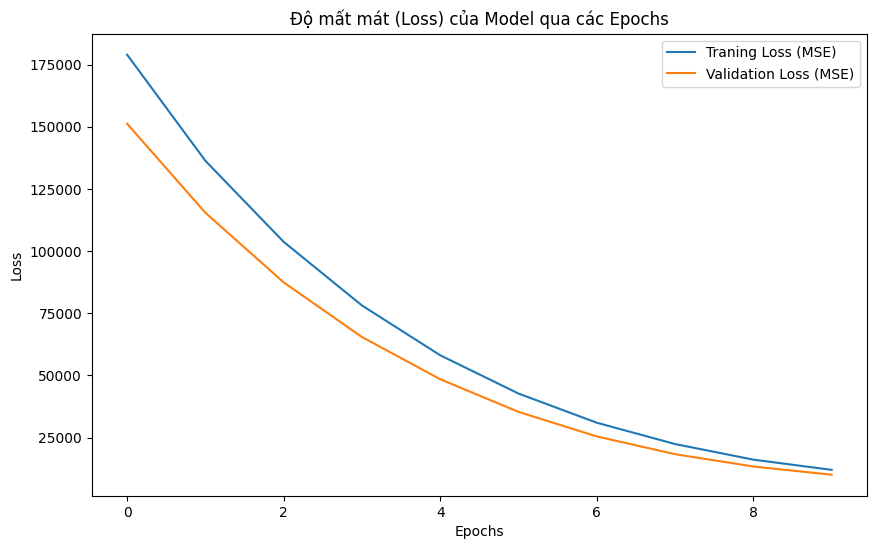


7. Đánh giá Model thực trên tập Test Set...
546/546 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 8325.2686
Test Loss (MSE - scaled format): 8325.2685546875
546/546 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


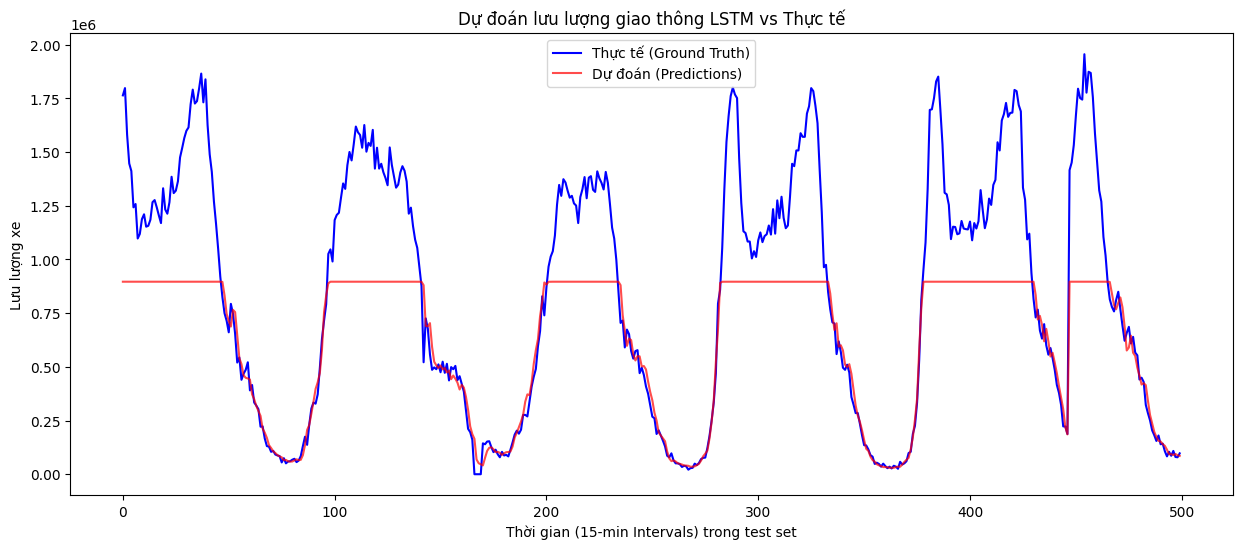

In [ ]:
print("\n6. Plotting Training History (Loss) Chart....")
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
    
print("\n7. Evaluating Model on Test Set...")
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (MSE - scaled format): {test_loss}")
    
# Predict on a segment of Test
predictions = model.predict(X_test)
    
# Inverse scale back to real numbers
predictions_denorm = scaler_y.inverse_transform(predictions)
y_test_denorm = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    
# Plot some frames comparing prediction vs actual results
plt.figure(figsize=(15, 6))
# Show first 500 data points in Test for easy viewing
plt.plot(y_test_denorm[:500], label='Actual (Ground Truth)', color='blue')
plt.plot(predictions_denorm[:500], label='Predictions', color='red', alpha=0.7)
plt.title('LSTM Traffic Volume Prediction vs Actual')
plt.xlabel('Time (15-min Intervals) in test set')
plt.ylabel('Vehicle Volume')
plt.legend()
plt.show()